<a href="https://colab.research.google.com/github/desaijay24/intrusion-detection-vanet-fl/blob/main/notebooks/iid_federated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Uninstall potentially incompatible versions
!pip uninstall -y flwr numpy

# flwr>=1.10.0 is needed for compatibility with NumPy 2.0 (and Python 3.12).
!pip install -q numpy==2.0.0
!pip install -q 'flwr[simulation]>=1.10.0' tensorflow scikit-learn pandas

Mounted at /content/drive
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you h

In [ ]:
import flwr as fl
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve


# # Uninstall numpy and related libraries that might have conflicting versions
# # It's important to uninstall scipy explicitly to ensure a clean slate.
!pip uninstall -y numpy scikit-learn tensorflow scipy

# # Install compatible numpy first
!pip install -q numpy==2.0.0

# # Then install scipy, which should be able to resolve to a version compatible with numpy 2.0.0
!pip install -q scipy

# # Then install scikit-learn, which depends on scipy and numpy
!pip install -q scikit-learn

# # Finally, install tensorflow, which also depends on numpy
!pip install -q tensorflow

# # Re-import numpy after re-installation
import numpy as np


Found existing installation: numpy 2.0.0
Uninstalling numpy-2.0.0:
  Successfully uninstalled numpy-2.0.0
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mapclassify 2.10.0 requires scikit-learn>=1.4, which is not installed.
mapclassify 2.10.0 requires scipy>=1.12, which is not installed.
stumpy 1.13.0 requires scipy>=1.10, which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
quantecon 0.11.1 requires scipy>=1.5.0, which is not installed.
xgboost 3.2.0 requires scipy,

In [ ]:
X = pd.read_csv("/content/drive/MyDrive/UNSW_X_preprocessed.csv")
y = pd.read_csv("/content/drive/MyDrive/UNSW_y.csv")

# If y is a DF with one column
if y.shape[1] == 1:
    y = y.iloc[:, 0]

X = X.values.astype("float32")
y = y.values.astype("int32")

print(X.shape, y.shape)

(82332, 25) (82332,)


In [ ]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train_all.shape, "Test:", X_test.shape)


Train: (65865, 25) Test: (16467, 25)


In [ ]:
NUM_CLIENTS = 4

# Shuffle indices
rng = np.random.RandomState(42)
indices = np.arange(len(X_train_all))
rng.shuffle(indices)

client_splits = np.array_split(indices, NUM_CLIENTS)

client_data = []
for i, idxs in enumerate(client_splits):
    client_data.append((X_train_all[idxs], y_train_all[idxs]))
    print(f"Client {i} -> {len(idxs)} samples")

Client 0 -> 16467 samples
Client 1 -> 16466 samples
Client 2 -> 16466 samples
Client 3 -> 16466 samples


In [ ]:
def create_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')  # binary classification
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

input_dim = X.shape[1]


In [ ]:
class FLClient(fl.client.NumPyClient):
    def __init__(self, X, y):
        self.model = create_model(input_dim)
        self.X = X
        self.y = y

    def get_parameters(self, config=None):
        return self.model.get_weights()

    def set_parameters(self, parameters):
        self.model.set_weights(parameters)

    def fit(self, parameters, config=None):
        self.set_parameters(parameters)
        self.model.fit(self.X, self.y, epochs=10, batch_size=32, verbose=0)
        return self.get_parameters(), len(self.X), {}

    def evaluate(self, parameters, config=None):
        self.set_parameters(parameters)
        loss, acc = self.model.evaluate(self.X, self.y, verbose=0)
        return loss, len(self.X), {"accuracy": acc}


In [ ]:
best_acc = 0
patience = 2
wait = 0

In [ ]:
def global_evaluate(server_round, parameters, config):
    global best_acc, wait

    model = create_model(X_test.shape[1])
    model.set_weights(parameters)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    if acc > best_acc:
        best_acc = acc
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print(" Early stopping triggered at round", server_round)
        raise StopIteration

    return loss, {"accuracy": acc}

In [ ]:
strategy = fl.server.strategy.FedAvg(
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    fraction_fit=1.0,
    evaluate_fn=global_evaluate
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def evaluate_round(server_round, parameters, config):
    model = create_model(X_test.shape[1])
    model.set_weights(parameters)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n Round {server_round} Results")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    return 0.0, {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }


In [ ]:
!pip install -q ray

In [ ]:
import flwr as fl

NUM_CLIENTS = 4 # Added this line to define NUM_CLIENTS

def client_fn(cid):
    cid = int(cid)
    Xc, yc = client_data[cid]
    return FLClient(Xc, yc)

strategy = fl.server.strategy.FedAvg(
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    fraction_fit=1.0
)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

          

In [ ]:
# Collect final client weights
weights_list = []
for c in range(NUM_CLIENTS):
    Xc, yc = client_data[c]
    client = FLClient(Xc, yc)
    weights_list.append(client.get_parameters())

# Average weights
avg_weights = []
for weights in zip(*weights_list):
    avg_weights.append(np.mean(np.array(weights), axis=0))

global_model = create_model(input_dim)
global_model.set_weights(avg_weights)

print("Global model built from aggregated client weights.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Global model built from aggregated client weights.


In [ ]:
pred_probs = global_model.predict(X_test)
preds = np.argmax(pred_probs, axis=1)

print(classification_report(y_test, preds, digits=4))

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, zero_division=0)
rec = recall_score(y_test, preds, zero_division=0)
f1 = f1_score(y_test, preds, zero_division=0)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)


515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0     0.5145    0.6693    0.5818      7400
           1     0.6423    0.4845    0.5523      9067

    accuracy                         0.5676     16467
   macro avg     0.5784    0.5769    0.5671     16467
weighted avg     0.5848    0.5676    0.5656     16467

Accuracy: 0.5675593611465355
Precision: 0.6422514619883041
Recall: 0.4845042461674203
F1: 0.552335449801974


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
results_df = pd.DataFrame(X_test, columns=[f"f{i}" for i in range(X_test.shape[1])])
results_df["true"] = y_test
results_df["pred"] = preds
results_df["action"] = results_df["pred"].apply(lambda x: "BLOCK" if x == 1 else "ALLOW")

blocked = results_df[results_df["action"] == "BLOCK"]
blocked_path = "/content/drive/MyDrive/UNSW_blocked_predictions_FL2.csv"
blocked.to_csv(blocked_path, index=False)

print(f"Blocked flows saved to: {blocked_path}")
print("Total blocked:", len(blocked))
print("True attacks blocked:", sum((results_df["true"]==1) & (results_df["action"]=="BLOCK")))
print("False blocks:", sum((results_df["true"]==0) & (results_df["action"]=="BLOCK")))


Blocked flows saved to: /content/drive/MyDrive/UNSW_blocked_predictions_FL2.csv
Total blocked: 6840
True attacks blocked: 4393
False blocks: 2447


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np

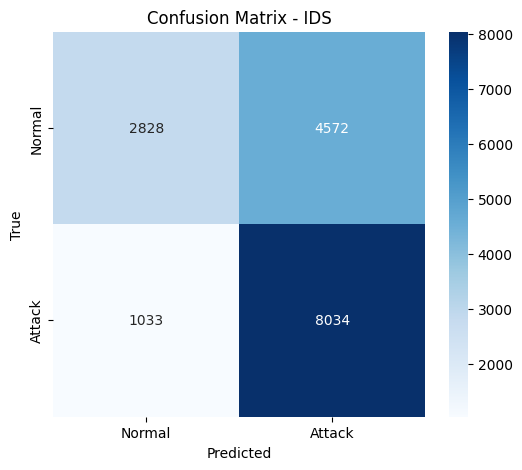

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("Confusion Matrix - IDS")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


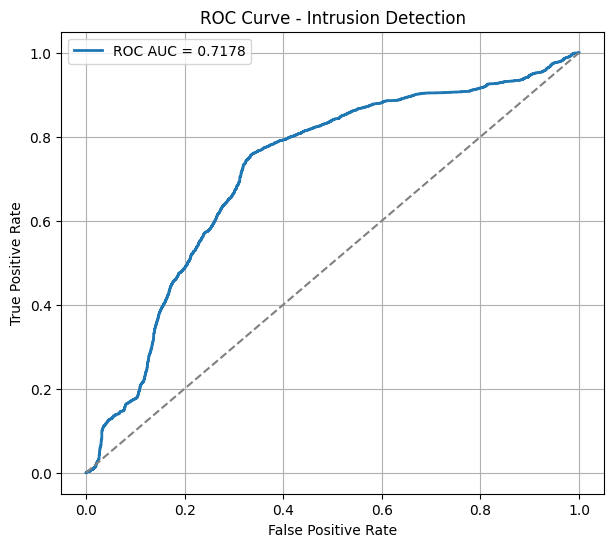

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
pred_probs = global_model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, pred_probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Intrusion Detection")
plt.legend()
plt.grid(True)
plt.show()

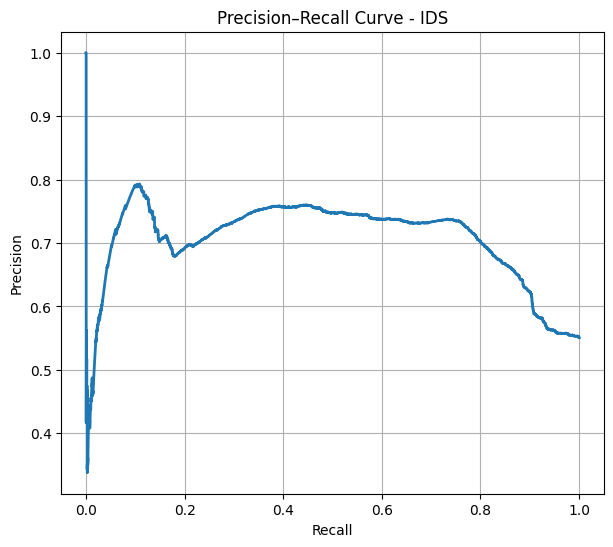

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_probs[:,1])

plt.figure(figsize=(7,6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - IDS")
plt.grid(True)
plt.show()


/tmp/ipython-input-2362512279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=preds, palette="viridis")


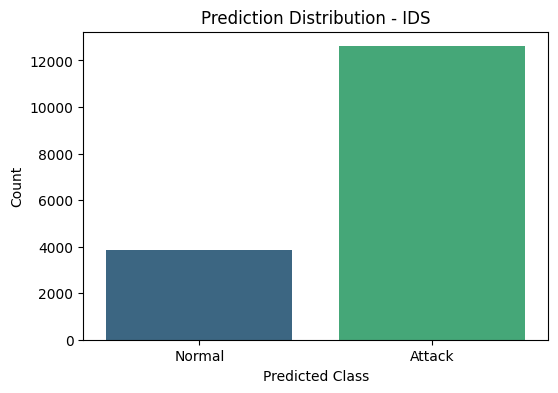

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=preds, palette="viridis")
plt.xticks([0,1], ["Normal", "Attack"])
plt.title("Prediction Distribution - IDS")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-2518185046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=results_df["action"], palette="magma")


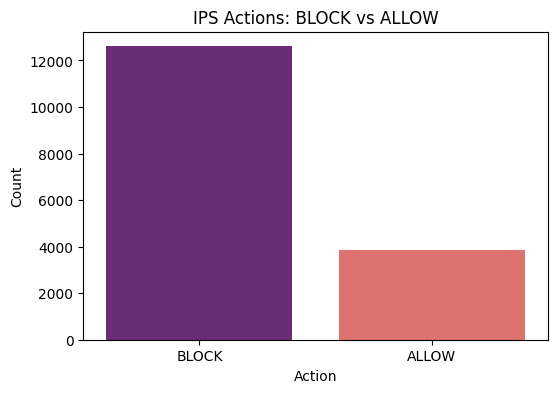

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=results_df["action"], palette="magma")
plt.title("IPS Actions: BLOCK vs ALLOW")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-2673397302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=attack_df["action"], palette="coolwarm")


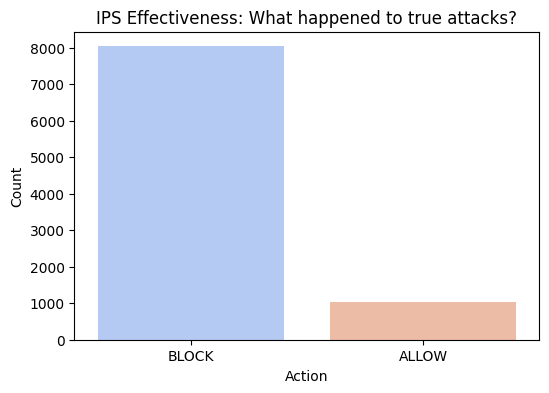

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
attack_df = results_df[results_df["true"] == 1]  # only attack samples

plt.figure(figsize=(6,4))
sns.countplot(x=attack_df["action"], palette="coolwarm")
plt.title("IPS Effectiveness: What happened to true attacks?")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()


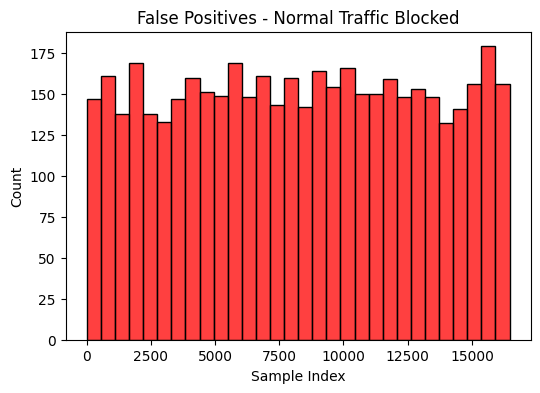

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fp_df = results_df[(results_df["true"] == 0) & (results_df["pred"] == 1)]

plt.figure(figsize=(6,4))
sns.histplot(fp_df.index, bins=30, color="red")
plt.title("False Positives - Normal Traffic Blocked")
plt.xlabel("Sample Index")
plt.ylabel("Count")
plt.show()

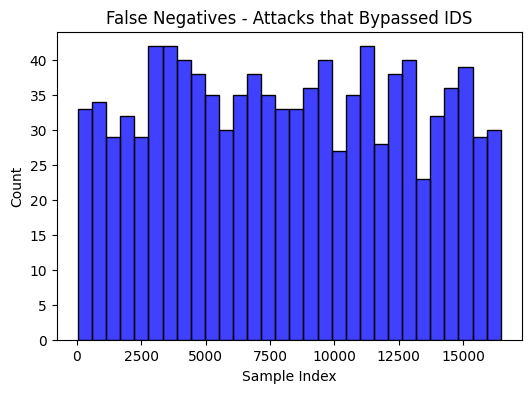

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fn_df = results_df[(results_df["true"] == 1) & (results_df["pred"] == 0)]

plt.figure(figsize=(6,4))
sns.histplot(fn_df.index, bins=30, color="blue")
plt.title("False Negatives - Attacks that Bypassed IDS")
plt.xlabel("Sample Index")
plt.ylabel("Count")
plt.show()